# hash table

1. 定义：
    哈希表（hash table），又称散列表，它通过建立键 key 与值 value 之间的映射，实现高效的元素查询。
    时间复杂度 k2v 查询 $O(1)$
    
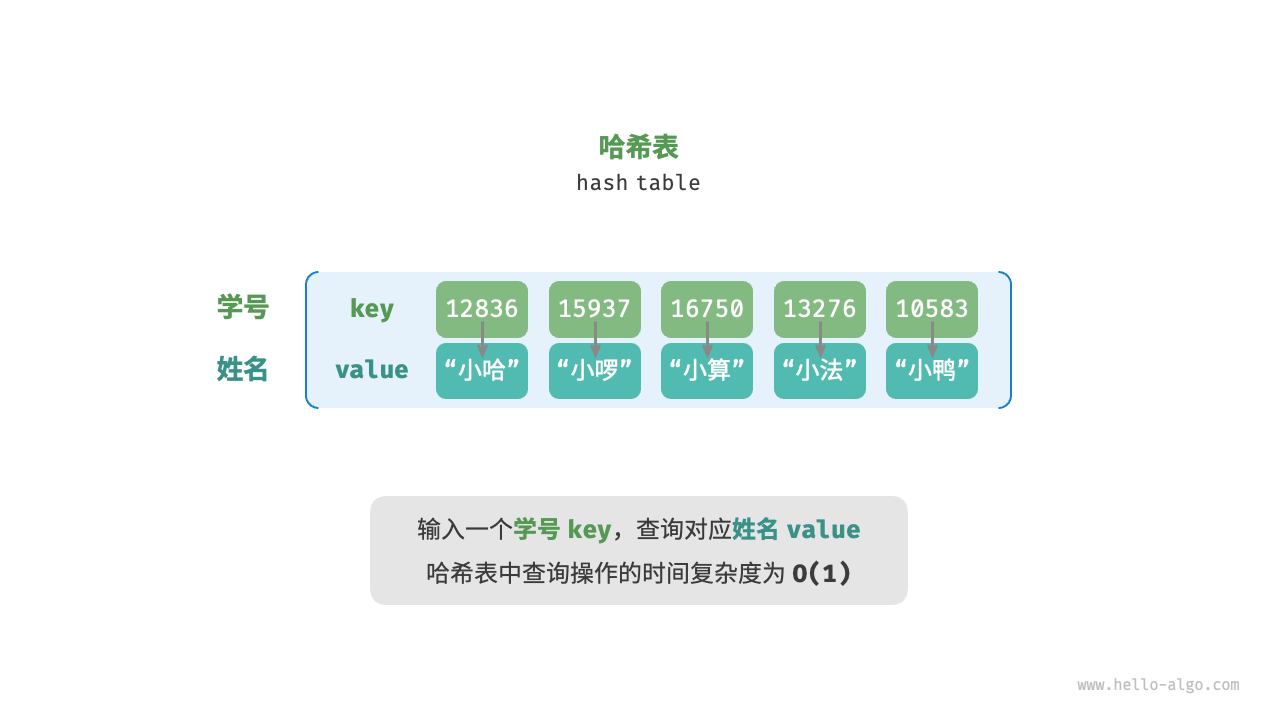

在哈希表中进行**增删查改的时间复杂度都是 $O(1)$**

In [2]:
# 初始化哈希表
hmap: dict = {}

# 添加操作
# 在哈希表中添加键值对 (key, value)
hmap[12836] = "小哈"
print(hmap)
hmap[15937] = "小啰"
hmap[16750] = "小算"
hmap[13276] = "小法"
hmap[10583] = "小鸭"
print(hmap)

# 查询操作
# 向哈希表中输入键 key ，得到值 value
name: str = hmap[15937]
print(name)

# 删除操作
# 在哈希表中删除键值对 (key, value)
hmap.pop(10583)
print(hmap)

{12836: '小哈'}
{12836: '小哈', 15937: '小啰', 16750: '小算', 13276: '小法', 10583: '小鸭'}
小啰
{12836: '小哈', 15937: '小啰', 16750: '小算', 13276: '小法'}


哈希表有三种常用的遍历方式：**遍历键值对、遍历键和遍历值**。

In [3]:
# 遍历哈希表
# 遍历键值对 key->value
for key, value in hmap.items():
    print(key, "->", value)
# 单独遍历键 key
for key in hmap.keys():
    print(key)
# 单独遍历值 value
for value in hmap.values():
    print(value)

12836 -> 小哈
15937 -> 小啰
16750 -> 小算
13276 -> 小法
12836
15937
16750
13276
小哈
小啰
小算
小法


在哈希表中，我们将数组中的每个空位称为桶（bucket），每个桶可存储一个键值对。
- 查询：找到 key 对应的桶，并在桶中获取 value 
- 输入一个 key ，我们可以通过**哈希函数**得到该 key 对应的键值对在数组中的存储位置

In [5]:
class Pair:
    """键值对"""

    def __init__(self, key: int, val: str):
        self.key = key
        self.val = val

class ArrayHashMap:
    """基于数组实现的哈希表"""

    def __init__(self):
        """构造方法"""
        # 初始化数组，包含 100 个桶
        self.buckets: list[Pair | None] = [None] * 100

    def hash_func(self, key: int) -> int:
        """哈希函数"""
        index = key % 100
        return index

    def get(self, key: int) -> str | None:
        """查询操作"""
        index: int = self.hash_func(key)
        pair: Pair = self.buckets[index]
        if pair is None:
            return None
        return pair.val

    def put(self, key: int, val: str):
        """添加和更新操作"""
        pair = Pair(key, val)
        index: int = self.hash_func(key)
        self.buckets[index] = pair

    def remove(self, key: int):
        """删除操作"""
        index: int = self.hash_func(key)
        # 置为 None ，代表删除
        self.buckets[index] = None

    def entry_set(self) -> list[Pair]:
        """获取所有键值对"""
        result: list[Pair] = []
        for pair in self.buckets:
            if pair is not None:
                result.append(pair)
        return result

    def key_set(self) -> list[int]:
        """获取所有键"""
        result = []
        for pair in self.buckets:
            if pair is not None:
                result.append(pair.key)
        return result

    def value_set(self) -> list[str]:
        """获取所有值"""
        result = []
        for pair in self.buckets:
            if pair is not None:
                result.append(pair.val)
        return result

    def print(self):
        """打印哈希表"""
        for pair in self.buckets:
            if pair is not None:
                print(pair.key, "->", pair.val)

In [10]:
# 初始化哈希表
hmap = ArrayHashMap()

# 添加操作
# 在哈希表中添加键值对 (key, value)
hmap.put(12836, "小哈") 
hmap.put(15937,"小啰")
hmap.put(16750, "小算")
hmap.put(13276, "小法")
hmap.put(10583, "小鸭")
print(hmap)

# 查询操作
# 向哈希表中输入键 key ，得到值 value
name: str = hmap.get(15937)
print(name)

# 删除操作
# 在哈希表中删除键值对 (key, value)
hmap.remove(10583)
print(hmap)

print("\n遍历键值对 Key->Value")
for pair in hmap.entry_set():
	print(pair.key, "->", pair.val)

小啰

遍历键值对 Key->Value
12836 -> 小哈
15937 -> 小啰
16750 -> 小算
13276 -> 小法


## hash collision

两个学号指向了同一个姓名，这显然是不对的。我们将这种多个输入对应同一输出的情况称为哈希冲突（hash collision）。

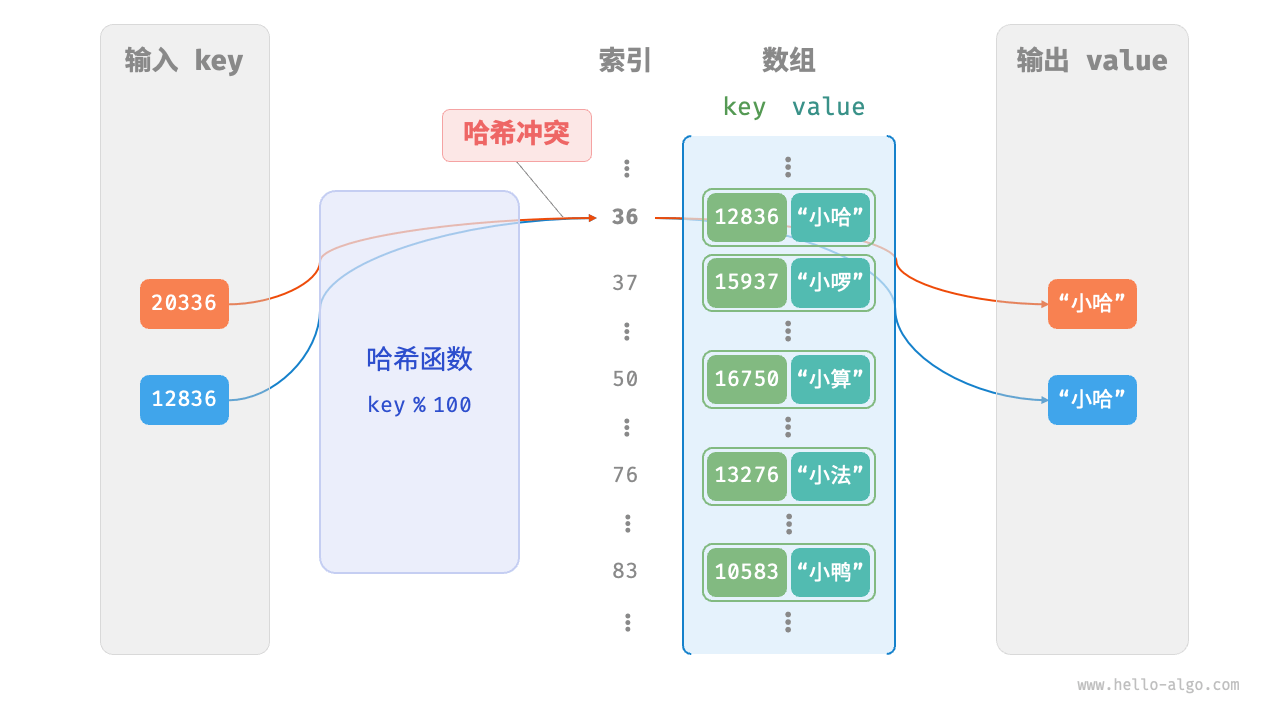

我们可以通过扩容哈希表来减少哈希冲突。

- 改良哈希表数据结构，使得哈希表可以在出现哈希冲突时正常工作。
- 仅在必要时，即当哈希冲突比较严重时，才执行扩容操作。
- 哈希表的结构改良方法主要包括 **“链式地址”** 和 **“开放寻址”**

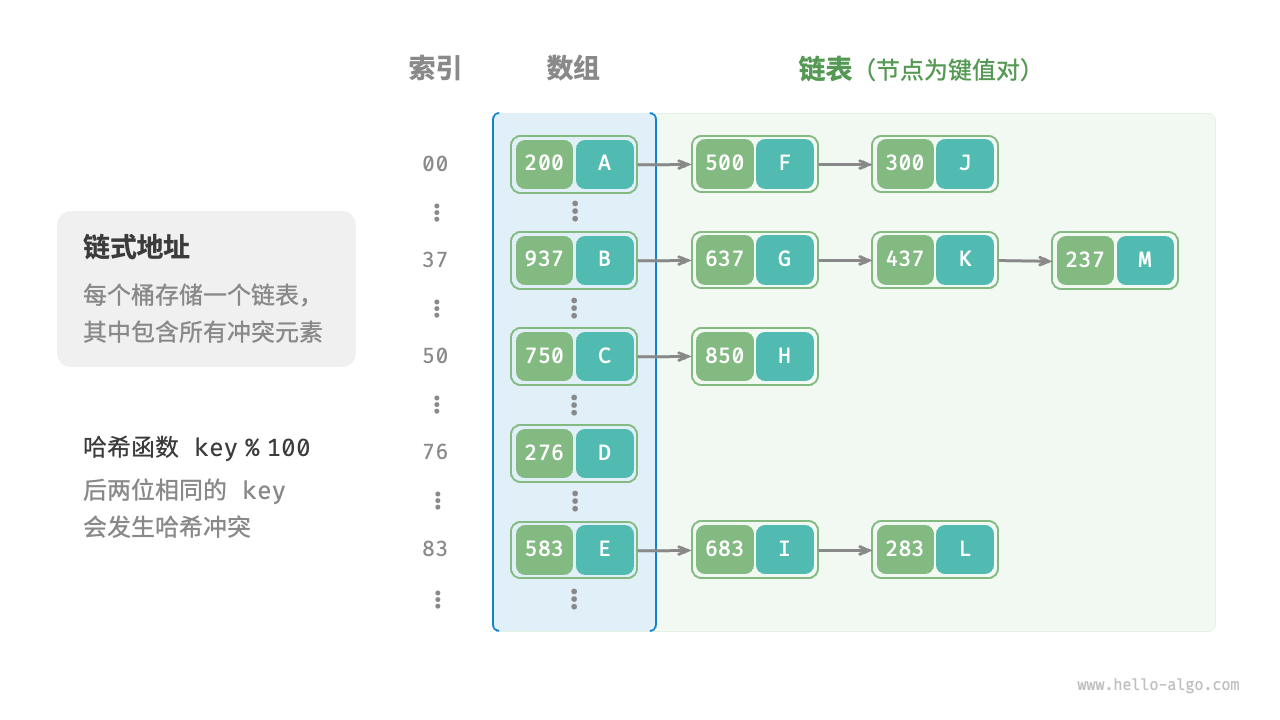

缺点：
占用空间大（链表的结点指针比数组消耗内存）
查询效率低（需要遍历链表）


In [13]:
class Pair:
    """键值对"""
    def __init__(self, key: int, val: str):
        self.key = key
        self.val = val

class HashMapChaining:
    """链式地址哈希表"""

    def __init__(self):
        """构造方法"""
        self.size = 0  # 键值对数量
        self.capacity = 4  # 哈希表容量
        self.load_thres = 2.0 / 3.0  # 触发扩容的负载因子阈值
        self.extend_ratio = 2  # 扩容倍数
        self.buckets = [[] for _ in range(self.capacity)]  # 桶数组

    def hash_func(self, key: int) -> int:
        """哈希函数"""
        return key % self.capacity

    def load_factor(self) -> float:
        """负载因子"""
        return self.size / self.capacity

    def get(self, key: int) -> str | None:
        """查询操作"""
        index = self.hash_func(key)
        bucket = self.buckets[index]
        # 遍历桶，若找到 key ，则返回对应 val
        for pair in bucket:
            if pair.key == key:
                return pair.val
        # 若未找到 key ，则返回 None
        return None

    def put(self, key: int, val: str):
        """添加操作"""
        # 当负载因子超过阈值时，执行扩容
        if self.load_factor() > self.load_thres:
            self.extend()
        index = self.hash_func(key)
        bucket = self.buckets[index]
        # 遍历桶，若遇到指定 key ，则更新对应 val 并返回
        for pair in bucket:
            if pair.key == key:
                pair.val = val
                return
        # 若无该 key ，则将键值对添加至尾部
        pair = Pair(key, val)
        bucket.append(pair)
        self.size += 1

    def remove(self, key: int):
        """删除操作"""
        index = self.hash_func(key)
        bucket = self.buckets[index]
        # 遍历桶，从中删除键值对
        for pair in bucket:
            if pair.key == key:
                bucket.remove(pair)
                self.size -= 1
                break

    def extend(self):
        """扩容哈希表"""
        # 暂存原哈希表
        buckets = self.buckets
        # 初始化扩容后的新哈希表
        self.capacity *= self.extend_ratio
        self.buckets = [[] for _ in range(self.capacity)]
        self.size = 0
        # 将键值对从原哈希表搬运至新哈希表
        for bucket in buckets:
            for pair in bucket:
                self.put(pair.key, pair.val)

    def print(self):
        """打印哈希表"""
        for bucket in self.buckets:
            res = []
            for pair in bucket:
                res.append(str(pair.key) + " -> " + pair.val)
            print(res)


In [14]:
def test_hashmap_chaining():
    print("=== 测试：链式地址哈希表 ===")

    # 1. 初始化哈希表
    hashmap = HashMapChaining()
    print(f"初始容量: {hashmap.capacity}, 初始负载因子: {hashmap.load_factor():.2f}")

    # 2. 插入元素
    hashmap.put(1, "A")
    hashmap.put(5, "B")  # 与 1 发生哈希冲突（如果 capacity=4）
    hashmap.put(9, "C")  # 同样冲突
    hashmap.put(13, "D") # 冲突链更长
    hashmap.put(2, "E")

    print("\n插入后：")
    hashmap.print()
    print(f"当前 size={hashmap.size}, load_factor={hashmap.load_factor():.2f}")

    # 3. 查询元素
    print("\n查询测试：")
    print("get(1) =", hashmap.get(1))   # 应输出 A
    print("get(5) =", hashmap.get(5))   # 应输出 B
    print("get(9) =", hashmap.get(9))   # 应输出 C
    print("get(100) =", hashmap.get(100))  # 不存在，返回 None

    # 4. 更新已存在键
    hashmap.put(5, "B_new")
    print("\n更新 key=5 后：")
    hashmap.print()
    print("get(5) =", hashmap.get(5))   # 应输出 B_new

    # 5. 删除键
    hashmap.remove(9)
    print("\n删除 key=9 后：")
    hashmap.print()
    print("get(9) =", hashmap.get(9))   # 应输出 None

    # 6. 测试扩容触发
    print("\n--- 插入更多数据以触发扩容 ---")
    for i in range(20, 40):
        hashmap.put(i, f"val{i}")
    hashmap.print()
    print(f"扩容后容量: {hashmap.capacity}, 当前负载因子: {hashmap.load_factor():.2f}")

    # 7. 校验扩容后数据是否保留
    print("\n扩容后数据验证：")
    for k in [1, 2, 5, 13, 25, 35]:
        print(f"key={k}, value={hashmap.get(k)}")

    print("\n✅ 测试结束 —— 所有核心功能运行完毕")


# 定义 Pair 和 HashMapChaining 后执行
if __name__ == "__main__":
    test_hashmap_chaining()


=== 测试：链式地址哈希表 ===
初始容量: 4, 初始负载因子: 0.00

插入后：
[]
['1 -> A', '9 -> C']
['2 -> E']
[]
[]
['5 -> B', '13 -> D']
[]
[]
当前 size=5, load_factor=0.62

查询测试：
get(1) = A
get(5) = B
get(9) = C
get(100) = None

更新 key=5 后：
[]
['1 -> A', '9 -> C']
['2 -> E']
[]
[]
['5 -> B_new', '13 -> D']
[]
[]
get(5) = B_new

删除 key=9 后：
[]
['1 -> A']
['2 -> E']
[]
[]
['5 -> B_new', '13 -> D']
[]
[]
get(9) = None

--- 插入更多数据以触发扩容 ---
[]
['1 -> A']
['2 -> E']
[]
[]
['5 -> B_new']
[]
[]
[]
[]
[]
[]
[]
['13 -> D']
[]
[]
[]
[]
[]
[]
['20 -> val20']
['21 -> val21']
['22 -> val22']
['23 -> val23']
['24 -> val24']
['25 -> val25']
['26 -> val26']
['27 -> val27']
['28 -> val28']
['29 -> val29']
['30 -> val30']
['31 -> val31']
['32 -> val32']
['33 -> val33']
['34 -> val34']
['35 -> val35']
['36 -> val36']
['37 -> val37']
['38 -> val38']
['39 -> val39']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
扩容后容量: 64, 当前负载因子: 0.38

扩容后数据验证：
key=1, value=A
key=2, value=E
key=5, value=B_new
key=13, value=D


## 开放寻址

- 线性探测采用固定步长的线性搜索来进行探测，其操作方法与普通哈希表有所不同。

    - **插入元素**：通过哈希函数计算桶索引，若发现桶内已有元素，则从冲突位置向后线性遍历（步长通常为 
    ），直至找到空桶，将元素插入其中。
    - **查找元素**：若发现哈希冲突，则使用相同步长向后进行线性遍历，直到找到对应元素，返回 value 即可；如果遇到空桶，说明目标元素不在哈希表中，返回 None 。

然而，线性探测容易产生“聚集现象”。

值得注意的是，我们不能在开放寻址哈希表中直接删除元素。

这是因为删除元素会在数组内产生一个空桶 None ，而当查询元素时，线性探测到该空桶就会返回，

`以下代码实现了一个包含懒删除的开放寻址（线性探测）哈希表。为了更加充分地使用哈希表的空间，我们将哈希表看作一个“环形数组”，当越过数组尾部时，回到头部继续遍历。`

In [15]:
class HashMapOpenAddressing:
    """开放寻址哈希表"""

    def __init__(self):
        """构造方法"""
        self.size = 0  # 键值对数量
        self.capacity = 4  # 哈希表容量
        self.load_thres = 2.0 / 3.0  # 触发扩容的负载因子阈值
        self.extend_ratio = 2  # 扩容倍数
        self.buckets: list[Pair | None] = [None] * self.capacity  # 桶数组
        self.TOMBSTONE = Pair(-1, "-1")  # 删除标记

    def hash_func(self, key: int) -> int:
        """哈希函数"""
        return key % self.capacity

    def load_factor(self) -> float:
        """负载因子"""
        return self.size / self.capacity

    def find_bucket(self, key: int) -> int:
        """搜索 key 对应的桶索引"""
        index = self.hash_func(key)
        first_tombstone = -1
        # 线性探测，当遇到空桶时跳出
        while self.buckets[index] is not None:
            # 若遇到 key ，返回对应的桶索引
            if self.buckets[index].key == key:
                # 若之前遇到了删除标记，则将键值对移动至该索引处
                if first_tombstone != -1:
                    self.buckets[first_tombstone] = self.buckets[index]
                    self.buckets[index] = self.TOMBSTONE
                    return first_tombstone  # 返回移动后的桶索引
                return index  # 返回桶索引
            # 记录遇到的首个删除标记
            if first_tombstone == -1 and self.buckets[index] is self.TOMBSTONE:
                first_tombstone = index
            # 计算桶索引，越过尾部则返回头部
            index = (index + 1) % self.capacity
        # 若 key 不存在，则返回添加点的索引
        return index if first_tombstone == -1 else first_tombstone

    def get(self, key: int) -> str:
        """查询操作"""
        # 搜索 key 对应的桶索引
        index = self.find_bucket(key)
        # 若找到键值对，则返回对应 val
        if self.buckets[index] not in [None, self.TOMBSTONE]:
            return self.buckets[index].val
        # 若键值对不存在，则返回 None
        return None

    def put(self, key: int, val: str):
        """添加操作"""
        # 当负载因子超过阈值时，执行扩容
        if self.load_factor() > self.load_thres:
            self.extend()
        # 搜索 key 对应的桶索引
        index = self.find_bucket(key)
        # 若找到键值对，则覆盖 val 并返回
        if self.buckets[index] not in [None, self.TOMBSTONE]:
            self.buckets[index].val = val
            return
        # 若键值对不存在，则添加该键值对
        self.buckets[index] = Pair(key, val)
        self.size += 1

    def remove(self, key: int):
        """删除操作"""
        # 搜索 key 对应的桶索引
        index = self.find_bucket(key)
        # 若找到键值对，则用删除标记覆盖它
        if self.buckets[index] not in [None, self.TOMBSTONE]:
            self.buckets[index] = self.TOMBSTONE
            self.size -= 1

    def extend(self):
        """扩容哈希表"""
        # 暂存原哈希表
        buckets_tmp = self.buckets
        # 初始化扩容后的新哈希表
        self.capacity *= self.extend_ratio
        self.buckets = [None] * self.capacity
        self.size = 0
        # 将键值对从原哈希表搬运至新哈希表
        for pair in buckets_tmp:
            if pair not in [None, self.TOMBSTONE]:
                self.put(pair.key, pair.val)

    def print(self):
        """打印哈希表"""
        for pair in self.buckets:
            if pair is None:
                print("None")
            elif pair is self.TOMBSTONE:
                print("TOMBSTONE")
            else:
                print(pair.key, "->", pair.val)